In [1]:
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Opening Image Using Pillow Library**

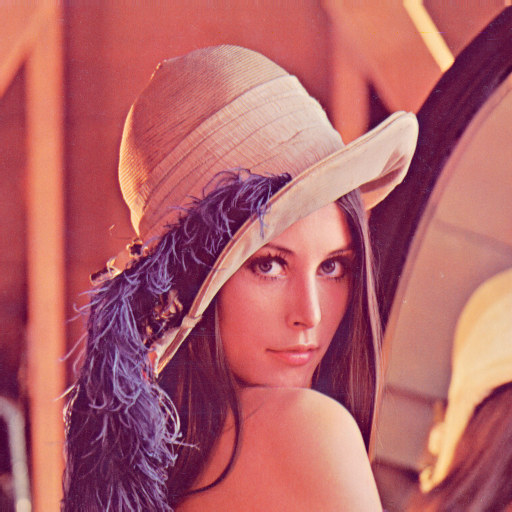

In [2]:
lena = Image.open('/content/drive/MyDrive/Root folder/Semester 6/Artificial Intelligence/Week 1/Workshop/Lena.png')
display(lena) # Displaying the opened image

**Creating an Array of the Opened Image**

In [3]:
import numpy as np

# Creating an array of the opened image for numpy operations
lenaArray = np.array(lena)

print("The shape of Lena Image: ", lenaArray.shape)
print("The format of Lena Image: ", lena.format) # format is only accessible by image but not array of the image
print("The mode of Lena Image: ", lena.mode)
print(f"Hence, the Image is defined by {lena.getbands()} channels.")

The shape of Lena Image:  (512, 512, 3)
The format of Lena Image:  PNG
The mode of Lena Image:  RGB
Hence, the Image is defined by ('R', 'G', 'B') channels.


**Displaying the Top-Left Corner (100*100)**

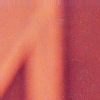

The size of the cropped image is:  (100, 100)


In [4]:
left = 0 # Horizontal Starting Point
upper = 0 # Vertical Starting Point
right = 100 # Horizontal Ending Point
bottom = 100 # Vertical Ending Point

display(lena.crop((left, upper, right, bottom)))
print("The size of the cropped image is: ", lena.crop((left, upper, right, bottom)).size)

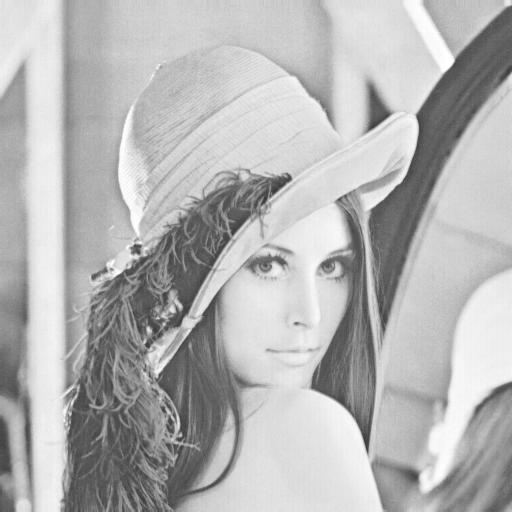

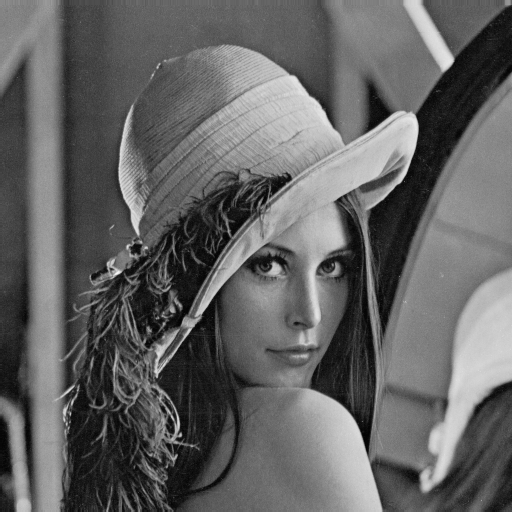

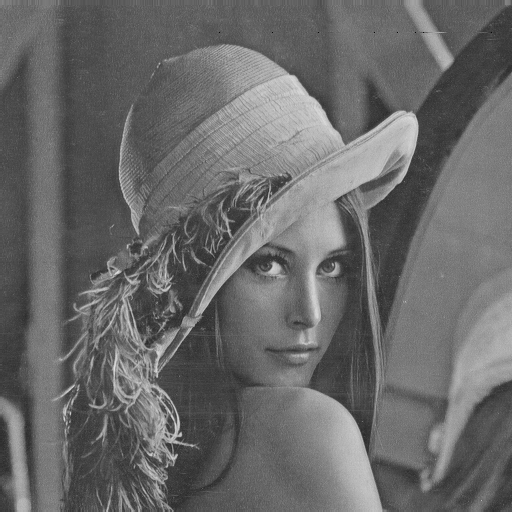

In [5]:
Red, Green, Blue = lena.split()

display(Red)
display(Green)
display(Blue)

**Obtaining the Intensity of each Pixels using Numpy Operations**

The Red Channel of Lena Image: 


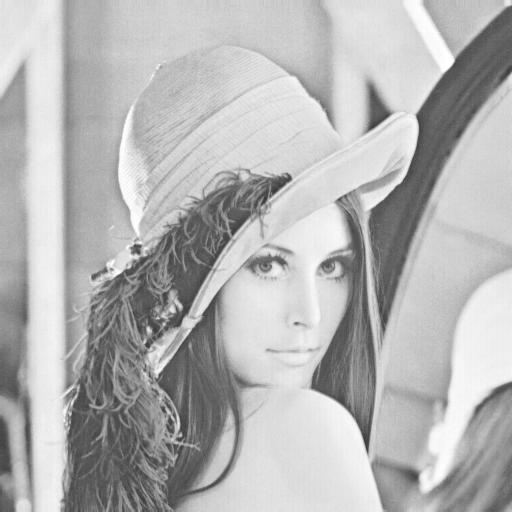

The Green Channel of Lena Image: 


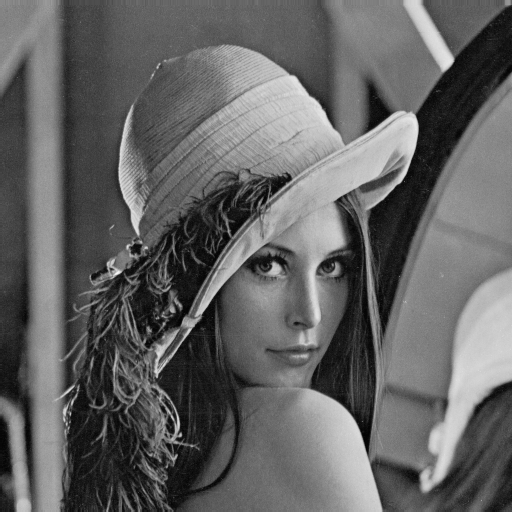

The Blue Channel of Lena Image: 


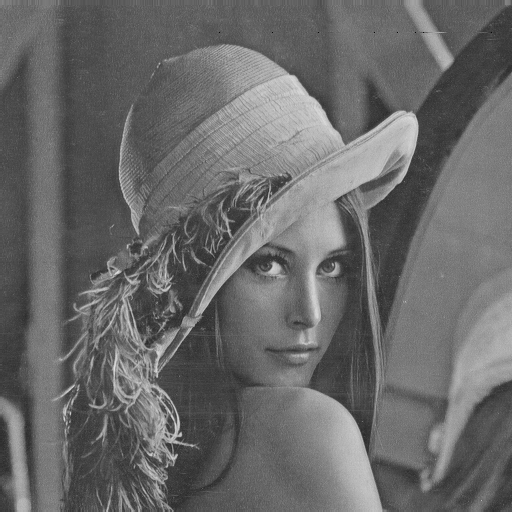

In [6]:
RedNumpy = lenaArray[:, :, 0]
GreenNumpy = lenaArray[:, :, 1]
BlueNumpy = lenaArray[:, :, 2]

print("The Red Channel of Lena Image: ")
display(Image.fromarray(RedNumpy)) # fromarray of pillow library converts back an array into an image

print("The Green Channel of Lena Image: ")
display(Image.fromarray(GreenNumpy))

print("The Blue Channel of Lena Image: ")
display(Image.fromarray(BlueNumpy))

array([[[210, 210, 210],
        [210, 210, 210],
        [210, 210, 210],
        ...,
        [230, 148, 122],
        [221, 130, 110],
        [200,  99,  90]],

       [[210, 210, 210],
        [210, 210, 210],
        [210, 210, 210],
        ...,
        [230, 148, 122],
        [221, 130, 110],
        [200,  99,  90]],

       [[210, 210, 210],
        [210, 210, 210],
        [210, 210, 210],
        ...,
        [230, 148, 122],
        [221, 130, 110],
        [200,  99,  90]],

       ...,

       [[ 84,  18,  60],
        [ 84,  18,  60],
        [ 92,  27,  58],
        ...,
        [173,  73,  84],
        [172,  68,  76],
        [177,  62,  79]],

       [[ 82,  22,  57],
        [ 82,  22,  57],
        [ 96,  32,  62],
        ...,
        [179,  70,  79],
        [181,  71,  81],
        [185,  74,  81]],

       [[ 82,  22,  57],
        [ 82,  22,  57],
        [ 96,  32,  62],
        ...,
        [179,  70,  79],
        [181,  71,  81],
        [185,  74,  81]]], dtype=uint8)
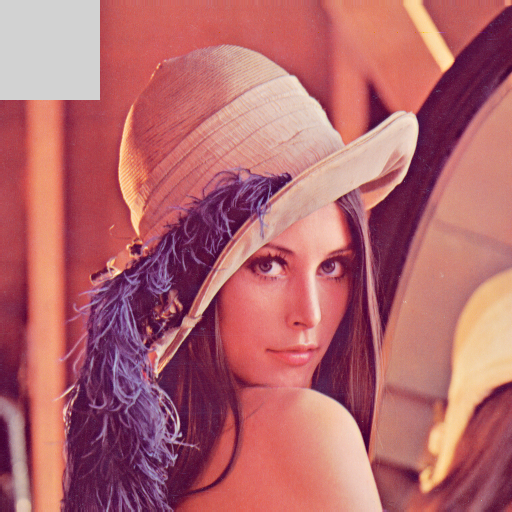

In [7]:
lenaArray[:100, :100] = 210 # Setting value of pixel channels to 210, of all rows and columns upto 100
display(lenaArray)

**Exercise - 2**

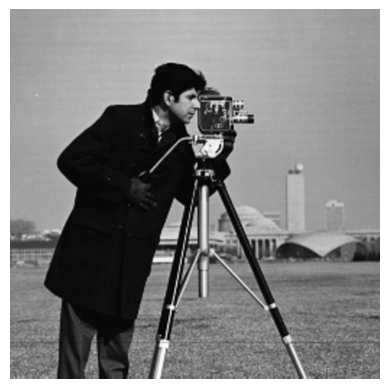

In [8]:
import matplotlib.pyplot as plt

cameramanImage = Image.open('/content/drive/MyDrive/Root folder/Semester 6/Artificial Intelligence/Week 1/Workshop/cameraman.png')
plt.imshow(cameramanImage, cmap = 'gray') # Displaying the image in grayscale
plt.axis("off") # Removing the axes scale
plt.show()


In [9]:
cameramanArray = np.array(cameramanImage)
width, height = cameramanArray.shape

print("The width of Cameraman Image: ", width)
print("The height of Cameraman Image: ", height)

The width of Cameraman Image:  512
The height of Cameraman Image:  512


**Calculating the Area to be Cropped**

In [10]:
cropSize = 150
startX = (width - cropSize) / 2
endX = (width + cropSize) / 2
startY = (height - cropSize) / 2
endY = (height + cropSize) / 2

cropImage = cameramanImage.crop((startX, startY, endX, endY)) # Assigning the cropped image to 'cropImage'

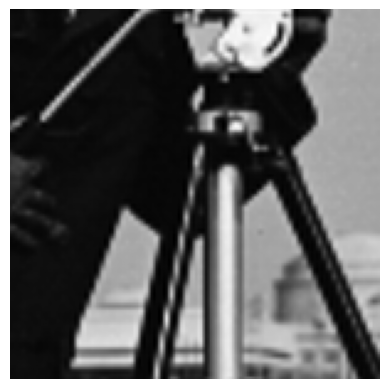

In [11]:
plt.imshow(cropImage, cmap='gray')
plt.axis("off")
plt.show()

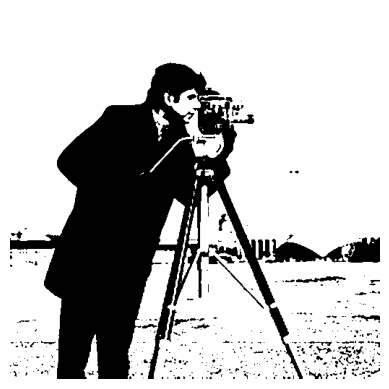

In [12]:
binaryImage = np.where(cameramanArray < 100, 0, 255)
plt.imshow(binaryImage, cmap='gray')
plt.axis("off")
plt.show()

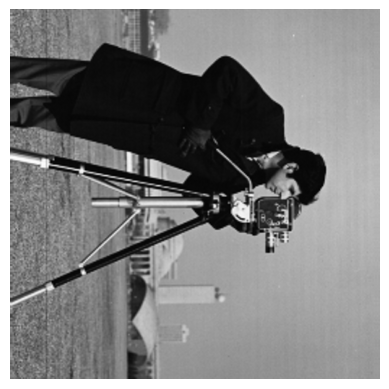

In [13]:
clockWiseRotation = cameramanImage.rotate(-90, expand=True)
plt.imshow(clockWiseRotation, cmap="gray")
plt.axis("off")
plt.show()

**Exercise 3**

In [14]:
ht, wth = cameramanArray.shape
print("The height of Cameraman Image: ", ht)
print("The width of Cameraman Image: ", wth)

cameramanData = cameramanArray.reshape(ht, wth)

The height of Cameraman Image:  512
The width of Cameraman Image:  512


In [15]:
mean = np.mean(cameramanData, axis = 0)
centeredData = cameramanData - mean
print(centeredData)

[[ 14.14648438  14.64648438  16.93164062 ...  21.046875    21.33984375
   21.4296875 ]
 [ 14.14648438  14.64648438  15.93164062 ...  21.046875    21.33984375
   21.4296875 ]
 [ 16.14648438  14.64648438  12.93164062 ...  21.046875    21.33984375
   21.4296875 ]
 ...
 [-20.85351562 -19.35351562 -17.06835938 ...  -9.953125   -17.66015625
  -19.5703125 ]
 [-20.85351562 -19.35351562 -17.06835938 ...  -9.953125   -17.66015625
  -19.5703125 ]
 [-20.85351562 -19.35351562 -17.06835938 ...  -9.953125   -17.66015625
  -19.5703125 ]]


In [29]:
covMatrix = np.cov(centeredData, rowvar=False)
print(covMatrix)
print(covMatrix.shape)

[[543.51861775 520.97947881 492.56189228 ... 452.37668175 465.56655914
  469.92323569]
 [520.97947881 515.55188585 504.98165744 ... 438.16924535 451.13798771
  455.28722786]
 [492.56189228 504.98165744 514.61175621 ... 415.396557   428.0037075
  431.84547762]
 ...
 [452.37668175 438.16924535 415.396557   ... 694.40484344 701.46153376
  705.1383317 ]
 [465.56655914 451.13798771 428.0037075  ... 701.46153376 724.80795927
  732.40163283]
 [469.92323569 455.28722786 431.84547762 ... 705.1383317  732.40163283
  741.0831091 ]]
(512, 512)


In [30]:
eigenValues, eigenVectors = np.linalg.eigh(covMatrix)
# print(eigenValue)
# print(eigenVector)

In [31]:
print(cameramanArray.shape) # The shape of the original image array
print(eigenValues.shape) # The shape of the 1D array of eigen-values
print(eigenVectors.shape) # The shape of the array of the eigen vectors

(512, 512)
(512,)
(512, 512)


In [32]:
sortedIndices = np.argsort(eigenValues)[::-1] # argsort returns an array of the indices of the elements. Firstly, the indices of elements are assigned based on the ascending values of the elements. However, the position of the indices remains in the same place as the original position of the element
eigenValues = eigenValues[sortedIndices]
eigenVectors = eigenVectors[:, sortedIndices]

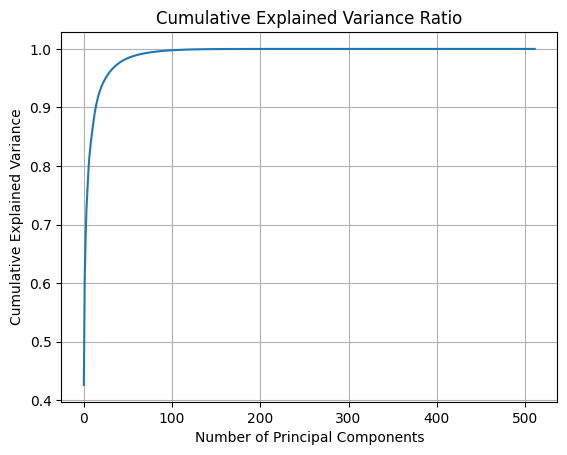

In [38]:
explainedVarianceRatio = eigenValues / np.sum(eigenValues)
plt.plot(np.cumsum(explainedVarianceRatio))
plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [44]:
k = 10
k2 = 50
k3 = 60
k4 = 80
components = eigenVectors[:, :k]
components2 = eigenVectors[:, :k2]
components3 = eigenVectors[:, :k3]
components4 = eigenVectors[:, :k4]
# print(components.shape)

In [45]:
compressedData = np.dot(centeredData , components )
compressedData2 = np.dot(centeredData , components2 )
compressedData3 = np.dot(centeredData , components3 )
compressedData4 = np.dot(centeredData , components4 )


In [46]:
decompressedData = np.dot(compressedData, components.T) + mean
decompressedData2 = np.dot(compressedData2, components2.T) + mean
decompressedData3 = np.dot(compressedData3, components3.T) + mean
decompressedData4 = np.dot(compressedData4, components4.T) + mean

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

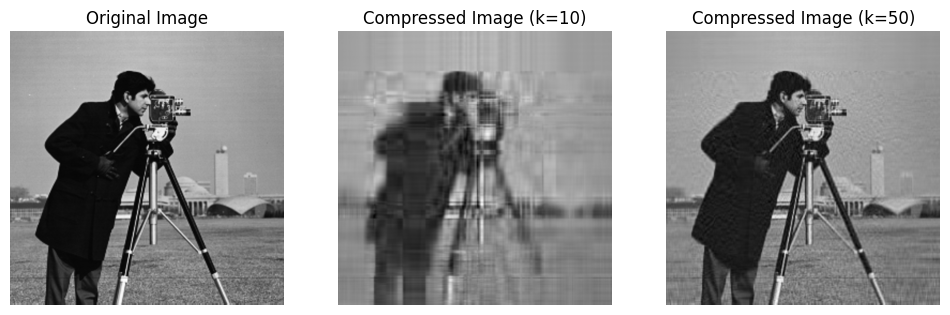

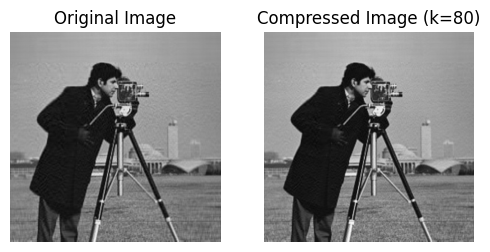

In [61]:
from matplotlib import cm
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(cameramanArray, cmap='gray')
plt.title('Original Image')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(decompressedData, cmap='gray')
plt.title(f'Compressed Image (k={k})')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(decompressedData2, cmap='gray')
plt.title(f'Compressed Image (k={k2})')
plt.axis("off")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.imshow(decompressedData3, cmap='gray')
plt.title('Original Image')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(decompressedData4, cmap='gray')
plt.title(f'Compressed Image (k={k4})')
plt.axis("off")